    Make    Model  Year  Engine Size  Mileage Fuel Type Transmission         Price
0  Honda  Model B  2015          3.9    74176    Petrol       Manual  30246.207931
1   Ford  Model C  2014          1.7    94799  Electric    Automatic  22785.747684
2    BMW  Model B  2006          4.1    98385  Electric       Manual  25760.290347
3  Honda  Model B  2015          2.6    88919  Electric    Automatic  25638.003491
4  Honda  Model C  2004          3.4   138482    Petrol    Automatic  21021.386657
5   Ford  Model C  2015          2.7    81462  Electric       Manual  25509.932876
6   Audi  Model B  2000          1.3   179340    Diesel       Manual  12268.206025
7   Audi  Model C  2018          2.0   165320  Electric    Automatic  27783.737881
8  Honda  Model A  2004          4.4    31159  Electric    Automatic  27392.178421
9   Ford  Model C  2006          4.4    42039  Electric    Automatic  28434.533624


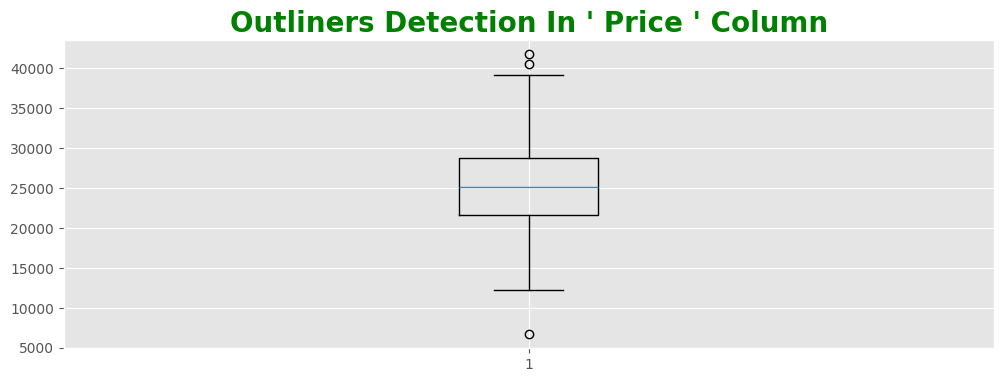

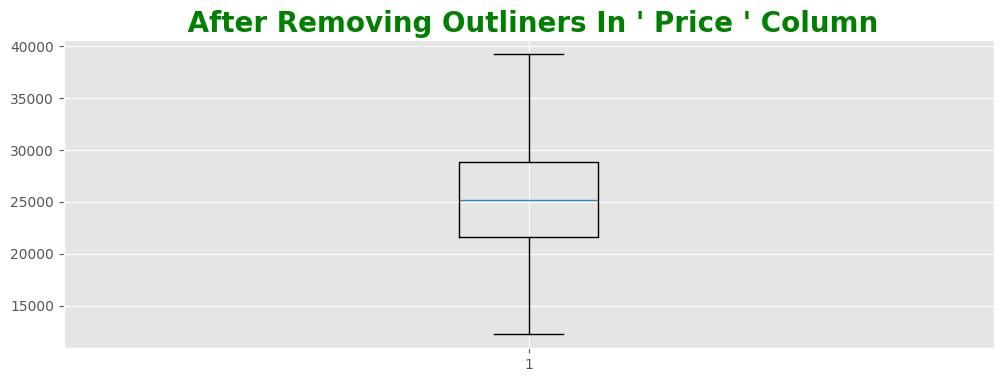

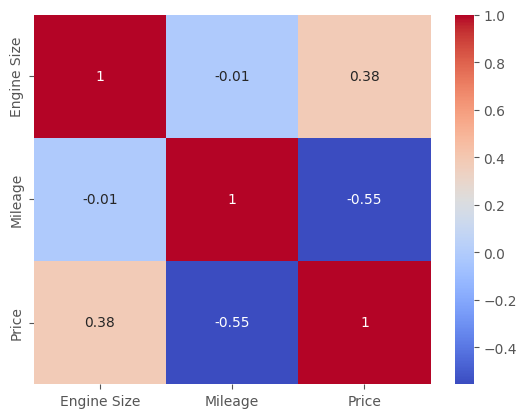

   Make    Model  Year  Engine Size  Mileage  Fuel Type  Transmission         Price  Engine Mileage       xyz  Car_Year  Mileage_Year
0     3  Model B  2015          3.9    74176          2             1  30246.207931        289286.4   74179.9        11     36.811911
1     2  Model C  2014          1.7    94799          1             0  22785.747684        161158.3   94800.7        12     47.070010
2     1  Model B  2006          4.1    98385          1             1  25760.290347        403378.5   98389.1        20     49.045364
3     3  Model B  2015          2.6    88919          1             0  25638.003491        231189.4   88921.6        11     44.128536
4     3  Model C  2004          3.4   138482          2             0  21021.386657        470838.8  138485.4        22     69.102794
5     2  Model C  2015          2.7    81462          1             1  25509.932876        219947.4   81464.7        11     40.427792
6     0  Model B  2000          1.3   179340          0       

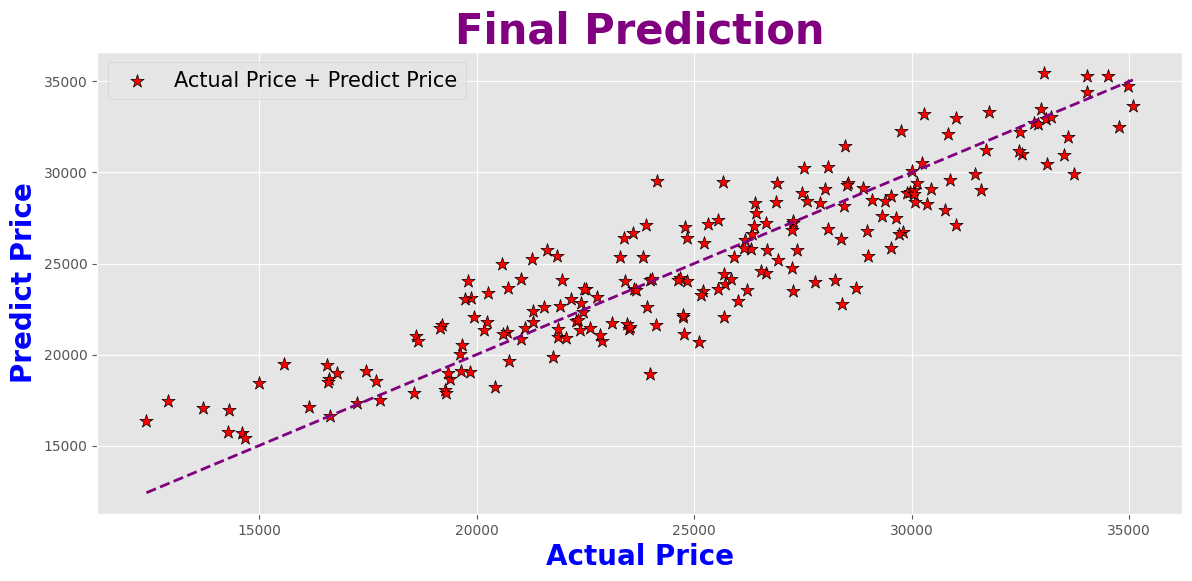

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')

pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',None)
pd.set_option('display.width',None)
pd.set_option('display.expand_frame_repr',False)

JP=pd.read_csv("Car_Price_Prediction.csv")

print(JP.head(10))
# print(JP.columns)

# print(JP.isnull().sum())

# ABC=JP.duplicated()
# print(ABC.tail(20))

plt.figure(figsize=(12,4))
plt.boxplot(JP['Price'])
plt.title("Outliners Detection In ' Price ' Column",fontsize=20,fontweight="bold",color='Green')
plt.show()

Q1=JP['Price'].quantile(0.25)
Q3=JP['Price'].quantile(0.75)

IQR=Q3-Q1

lower=Q1 - 1.5 * IQR
upper=Q3 + 1.5 * IQR

JP=JP[(JP['Price'] >= (lower)) & (JP['Price'] <= (upper))]


plt.figure(figsize=(12,4))
plt.boxplot(JP['Price'])
plt.title(" After Removing Outliners In ' Price ' Column",fontsize=20,fontweight="bold",color='Green')
plt.show()


from sklearn.preprocessing import LabelEncoder

JP['Make']=LabelEncoder().fit_transform(JP['Make'])
JP['Fuel Type']=LabelEncoder().fit_transform(JP['Fuel Type'])
JP['Transmission']=LabelEncoder().fit_transform(JP['Transmission'])


ac=JP[['Engine Size','Mileage','Price']]
sns.heatmap(ac.corr(),annot=True,cmap='coolwarm')
plt.show()

# from sklearn.preprocessing import StandardScaler

# JP[['Engine Size','Mileage']]=StandardScaler().fit_transform(JP[['Engine Size','Mileage']])


JP['Engine Mileage']=JP['Engine Size'] * JP['Mileage'] 
JP['xyz']=JP['Engine Size'] + JP['Mileage']
JP['Car_Year']=2026 - JP['Year']
JP['Mileage_Year']= JP['Mileage'] / JP['Year']

print(JP.head(10))

x=JP[['Make','Year','Engine Size','Mileage','Fuel Type','Transmission','Engine Mileage','xyz','Car_Year','Mileage_Year'
    ]]
y=JP['Price']


from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

model=LinearRegression()

score=cross_val_score(model,x,y,cv=5,scoring="r2")
print("Cross Validation Scores ",score)
print("Average CVS ",score.mean())


from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,r2_score

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=76)


from sklearn.linear_model import LinearRegression

lr=LinearRegression()
lr.fit(x_train,y_train)

Y_Pred=lr.predict(x_test)

Train_Score=lr.score(x_train,y_train)
Test_Score=lr.score(x_test,y_test)

print("Train Score ==",Train_Score)
print("Test Score ==",Test_Score)

print("MAE For LinearRegression",mean_absolute_error(y_test,Y_Pred))
print("R2 For LinearRegression",r2_score(y_test,Y_Pred))


# from sklearn.ensemble import RandomForestRegressor 

# dtr=RandomForestRegressor()
# dtr.fit(x_train,y_train)

# Y_Pred=dtr.predict(x_test)

# score=cross_val_score(dtr,x,y,cv=5,scoring="r2")
# print("Cross Validation Scores ",score)
# print("Average CVS ",score.mean())

# print("Train Score ==",Train_Score)
# print("Test Score ==",Test_Score)

# print("MAE For RandomForest Regressor",mean_absolute_error(y_test,Y_Pred))
# print("R2 For  RandomForest Regressor",r2_score(y_test,Y_Pred))


plt.figure(figsize=(14,6))
plt.scatter(y_test,Y_Pred,marker="*",s=100,color='red',edgecolors='black',label='Actual Price + Predict Price')
plt.plot(   [y_test.min(),y_test.max()]  ,  [y_test.min(),y_test.max()],linestyle="--" ,linewidth=2 ,color='purple' )
plt.xlabel("Actual Price",color='blue',fontsize=20,fontweight='bold')
plt.ylabel("Predict Price",color='blue',fontsize=20,fontweight='bold')
plt.title("Final Prediction",fontsize=30,fontweight="bold",color='Purple')
plt.legend(loc='upper left',fontsize=15)
plt.show()